# Padparadscha Log Analyzer

This notebook loads one of the board CSV log files, parses the metadata header, plots the useful metrics, and renders an animated cross-section view for the radial sensors.

How to use:
1. Change `CSV_PATH` in the next cell to your log file.
2. Run all cells.
3. Inspect the static plots and the animated radial view.

The notebook expects the CSV format currently generated by the firmware in `Core/Src/storage_logger.c`.

In [1]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

# Point this to the log you want to analyze.
CSV_PATH = Path("LOG_0001.CSV")

# Animation tuning.
MAX_ANIMATION_FRAMES = 300
ANIMATION_INTERVAL_MS = 50
SENSOR_RING_RADIUS = 1.0
ARROW_SCALE_PA = 1.0

assert CSV_PATH.exists(), f"CSV file not found: {CSV_PATH}"

In [2]:
def parse_metadata(csv_path: Path):
    metadata = {}
    sensors = []
    with csv_path.open("r", encoding="utf-8", errors="replace") as handle:
        for line in handle:
            if not line.startswith("#"):
                break
            line = line.strip()
            parts = [part.strip() for part in line.split(",")]
            if not parts:
                continue
            key = parts[0].lstrip("#").strip()
            if key.startswith("Sensor") and len(parts) >= 6:
                sensors.append({
                    "key": key,
                    "label": parts[1],
                    "role": parts[2],
                    "angle_deg": float(parts[3]),
                    "inverted": bool(int(parts[4])),
                    "enabled": bool(int(parts[5])),
                })
            elif len(parts) >= 2:
                metadata[key] = ",".join(parts[1:]).strip()
    return metadata, sensors


def load_log(csv_path: Path):
    metadata, sensors = parse_metadata(csv_path)
    df = pd.read_csv(csv_path, comment="#")
    df.columns = [column.strip() for column in df.columns]

    object_columns = list(df.select_dtypes(include=["object"]).columns)
    for column in object_columns:
        df[column] = df[column].astype(str).str.strip()
        if column not in {"profile", "sensor1_role", "sensor2_role", "sensor3_role", "sensor4_role"}:
            df[column] = df[column].replace({"NA": np.nan, "nan": np.nan, "": np.nan})

    numeric_candidates = [
        column for column in df.columns
        if column not in {"profile", "sensor1_role", "sensor2_role", "sensor3_role", "sensor4_role"}
    ]
    for column in numeric_candidates:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    if "timestamp_us" in df.columns:
        df["time_s"] = df["timestamp_us"] / 1_000_000.0
        df["time_from_start_s"] = df["time_s"] - df["time_s"].iloc[0]

    return metadata, sensors, df


metadata, sensors, df = load_log(CSV_PATH)

display(pd.DataFrame([metadata]) if metadata else pd.DataFrame())
display(pd.DataFrame(sensors))
display(df.head())
print(f"Loaded {len(df)} rows from {CSV_PATH.name}")

/var/folders/3x/33x7_qkx0kjb4xhyss9m68440000gn/T/ipykernel_15051/1925369298.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = list(df.select_dtypes(include=["object"]).columns)


,Flight logger version,Profile,Sample rate Hz,Chunk duration s,Chunk start us
0,1.0.0,RADIAL_RING_V1,100,300,220722


,key,label,role,angle_deg,inverted,enabled
0,Sensor1,S1_FRONT,RADIAL,0.0,False,True
1,Sensor2,S2_RIGHT,RADIAL,90.0,False,True
2,Sensor3,S3_REAR,RADIAL,180.0,False,True
3,Sensor4,S4_LEFT,RADIAL,270.0,False,True


,timestamp_us,profile,sensor1_role,sensor1_pressure_pa,sensor1_temperature_c,sensor1_scale_factor,sensor1_status,sensor2_role,sensor2_pressure_pa,sensor2_temperature_c,sensor2_scale_factor,sensor2_status,sensor3_role,sensor3_pressure_pa,sensor3_temperature_c,sensor3_scale_factor,sensor3_status,sensor4_role,sensor4_pressure_pa,sensor4_temperature_c,sensor4_scale_factor,sensor4_status,pitot_dynamic_pressure_pa,pitot_airspeed_mps,radial_mean_pressure_pa,radial_spread_pa,radial_vector_x_pa,radial_vector_y_pa,radial_vector_magnitude_pa,radial_flow_angle_deg,static_mean_pressure_pa,time_s,time_from_start_s
0,894870,RADIAL_RING_V1,RADIAL,0.000,22.990,60,0,RADIAL,0.000,22.660,60,0,RADIAL,0.000,22.780,60,0,RADIAL,0.000,23.085,60,0,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.0,NaN,0.894870,0.000000
1,904871,RADIAL_RING_V1,RADIAL,0.000,22.990,60,0,RADIAL,0.016,22.660,60,0,RADIAL,0.000,22.780,60,0,RADIAL,-0.016,23.085,60,0,NaN,NaN,0.000,0.032,0.000,0.032,0.032,90.0,NaN,0.904871,0.010001
2,914869,RADIAL_RING_V1,RADIAL,0.000,22.995,60,0,RADIAL,0.000,22.710,60,0,RADIAL,0.000,22.800,60,0,RADIAL,0.016,23.080,60,0,NaN,NaN,0.004,0.016,0.000,-0.016,0.016,-90.0,NaN,0.914869,0.019999
3,924869,RADIAL_RING_V1,RADIAL,0.000,22.995,60,0,RADIAL,0.000,22.685,60,0,RADIAL,0.016,22.800,60,0,RADIAL,0.016,23.040,60,0,NaN,NaN,0.008,0.016,-0.016,-0.016,0.023,-135.0,NaN,0.924869,0.029999
4,934870,RADIAL_RING_V1,RADIAL,0.016,22.985,60,0,RADIAL,0.000,22.670,60,0,RADIAL,0.016,22.815,60,0,RADIAL,0.000,23.080,60,0,NaN,NaN,0.008,0.016,0.000,0.000,0.000,90.0,NaN,0.934870,0.040000


Loaded 3550 rows from LOG_0001.CSV


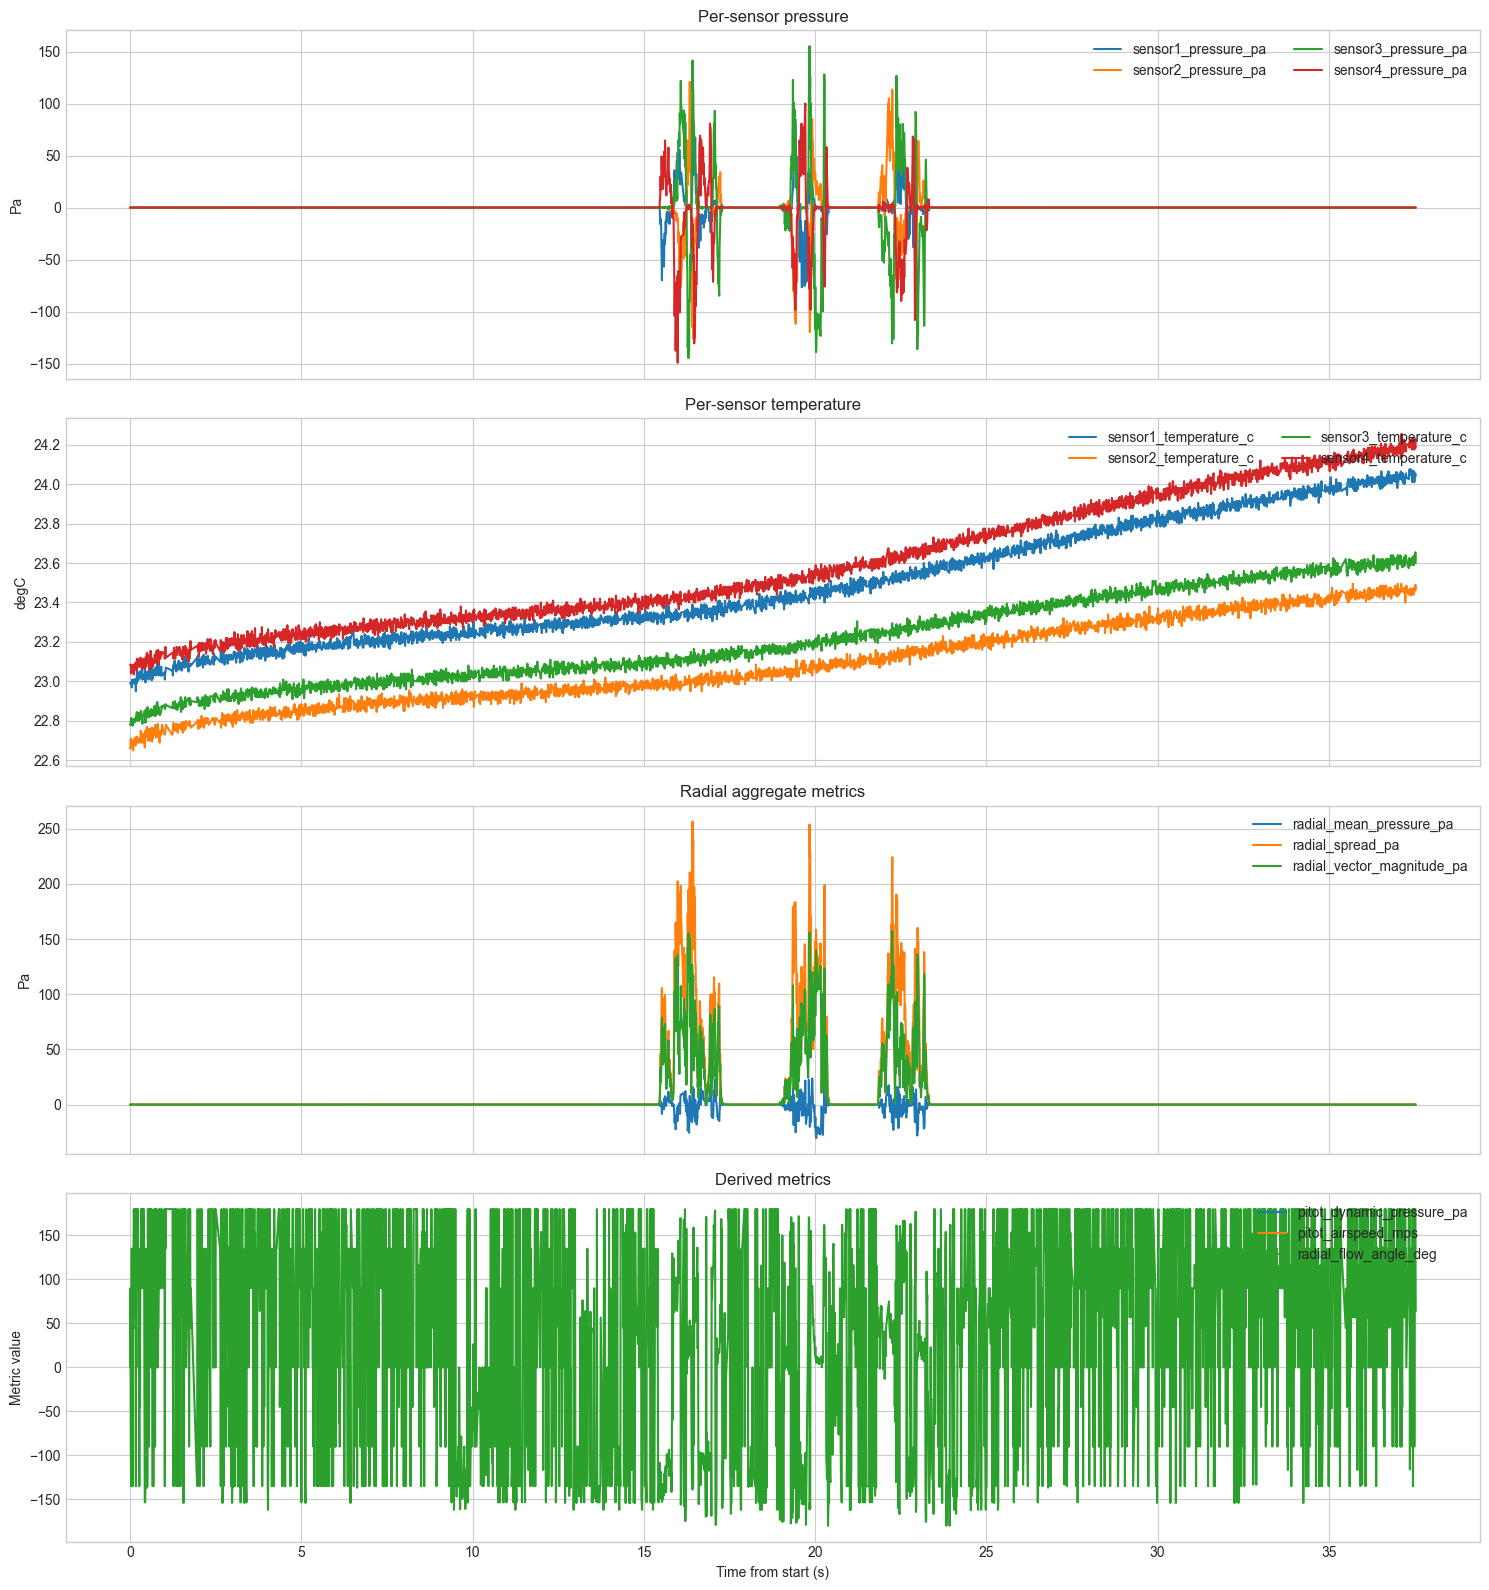

In [3]:
sensor_ids = [1, 2, 3, 4]
pressure_columns = [f"sensor{i}_pressure_pa" for i in sensor_ids]
temperature_columns = [f"sensor{i}_temperature_c" for i in sensor_ids]
status_columns = [f"sensor{i}_status" for i in sensor_ids]

metric_columns = [
    "pitot_dynamic_pressure_pa",
    "pitot_airspeed_mps",
    "radial_mean_pressure_pa",
    "radial_spread_pa",
    "radial_vector_x_pa",
    "radial_vector_y_pa",
    "radial_vector_magnitude_pa",
    "radial_flow_angle_deg",
    "static_mean_pressure_pa",
]

time_axis = df["time_from_start_s"] if "time_from_start_s" in df.columns else np.arange(len(df))

fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

for column in pressure_columns:
    if column in df.columns:
        axes[0].plot(time_axis, df[column], label=column)
axes[0].set_title("Per-sensor pressure")
axes[0].set_ylabel("Pa")
axes[0].legend(loc="upper right", ncol=2)

for column in temperature_columns:
    if column in df.columns:
        axes[1].plot(time_axis, df[column], label=column)
axes[1].set_title("Per-sensor temperature")
axes[1].set_ylabel("degC")
axes[1].legend(loc="upper right", ncol=2)

for column in ["radial_mean_pressure_pa", "radial_spread_pa", "radial_vector_magnitude_pa"]:
    if column in df.columns:
        axes[2].plot(time_axis, df[column], label=column)
axes[2].set_title("Radial aggregate metrics")
axes[2].set_ylabel("Pa")
axes[2].legend(loc="upper right")

for column in ["pitot_dynamic_pressure_pa", "pitot_airspeed_mps", "radial_flow_angle_deg"]:
    if column in df.columns:
        axes[3].plot(time_axis, df[column], label=column)
axes[3].set_title("Derived metrics")
axes[3].set_ylabel("Metric value")
axes[3].set_xlabel("Time from start (s)")
axes[3].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [4]:
summary = {}
for column in pressure_columns + temperature_columns + metric_columns:
    if column in df.columns:
        series = df[column].dropna()
        if not series.empty:
            summary[column] = {
                "min": float(series.min()),
                "max": float(series.max()),
                "mean": float(series.mean()),
                "std": float(series.std()) if len(series) > 1 else 0.0,
            }

summary_df = pd.DataFrame(summary).T.sort_index()
display(summary_df.style.format("{:.4f}"))

AttributeError: The '.style' accessor requires jinja2

In [ ]:
if not sensors:
    sensors = [
        {"label": "S1", "role": "RADIAL", "angle_deg": 0.0, "enabled": True, "inverted": False},
        {"label": "S2", "role": "RADIAL", "angle_deg": 90.0, "enabled": True, "inverted": False},
        {"label": "S3", "role": "RADIAL", "angle_deg": 180.0, "enabled": True, "inverted": False},
        {"label": "S4", "role": "RADIAL", "angle_deg": 270.0, "enabled": True, "inverted": False},
    ]

radial_sensors = [sensor for sensor in sensors if sensor["enabled"] and sensor["role"] == "RADIAL"]
anim_step = max(1, len(df) // MAX_ANIMATION_FRAMES) if len(df) else 1
anim_df = df.iloc[::anim_step].reset_index(drop=True).copy()

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_title("Radial flow visualization")
ax.set_xlabel("Rocket X axis")
ax.set_ylabel("Rocket Y axis")

rocket = plt.Circle((0, 0), SENSOR_RING_RADIUS, fill=False, linewidth=2, color="black")
ax.add_patch(rocket)
ax.axhline(0, color="lightgray", linewidth=1)
ax.axvline(0, color="lightgray", linewidth=1)

sensor_points = []
sensor_labels = []
for sensor in radial_sensors:
    angle_rad = math.radians(sensor["angle_deg"])
    x = SENSOR_RING_RADIUS * math.cos(angle_rad)
    y = SENSOR_RING_RADIUS * math.sin(angle_rad)
    point, = ax.plot([x], [y], marker="o", markersize=12, color="tab:blue")
    label = ax.text(x * 1.15, y * 1.15, sensor["label"], ha="center", va="center")
    sensor_points.append(point)
    sensor_labels.append((x, y, sensor))

vector_artist = ax.quiver([0], [0], [0], [0], angles="xy", scale_units="xy", scale=1, color="tab:red", width=0.01)
title_artist = ax.text(0, 1.45, "", ha="center", va="center", fontsize=12)


def value_to_color(value, limit):
    if np.isnan(value):
        return (0.7, 0.7, 0.7, 1.0)
    if limit <= 0:
        return (0.2, 0.2, 0.8, 1.0)
    normalized = max(-1.0, min(1.0, value / limit))
    if normalized >= 0:
        return (1.0, 1.0 - normalized, 1.0 - normalized, 1.0)
    return (1.0 + normalized, 1.0 + normalized, 1.0, 1.0)


pressure_limit = 1.0
if pressure_columns:
    available_pressures = [column for column in pressure_columns if column in anim_df.columns]
    if available_pressures:
        pressure_limit = max(1.0, float(anim_df[available_pressures].abs().max().max()))

vector_limit = 1.0
if "radial_vector_magnitude_pa" in anim_df.columns:
    vector_limit = max(1.0, float(anim_df["radial_vector_magnitude_pa"].abs().max()))


def init_animation():
    vector_artist.set_UVC([0], [0])
    title_artist.set_text("No data")
    return [vector_artist, title_artist, *sensor_points]


def update_animation(frame_index):
    row = anim_df.iloc[frame_index]
    for sensor_index, (_, _, sensor) in enumerate(sensor_labels, start=1):
        pressure_column = f"sensor{sensor_index}_pressure_pa"
        pressure_value = row.get(pressure_column, np.nan)
        sensor_points[sensor_index - 1].set_color(value_to_color(pressure_value, pressure_limit))

    vx = float(row.get("radial_vector_x_pa", 0.0)) / max(vector_limit, 1.0)
    vy = float(row.get("radial_vector_y_pa", 0.0)) / max(vector_limit, 1.0)
    vector_artist.set_UVC([vx], [vy])

    time_value = row.get("time_from_start_s", frame_index)
    spread_value = row.get("radial_spread_pa", np.nan)
    angle_value = row.get("radial_flow_angle_deg", np.nan)
    title_artist.set_text(
        f"t={time_value:.3f}s  spread={spread_value:.3f} Pa  angle={angle_value:.2f} deg"
    )
    return [vector_artist, title_artist, *sensor_points]


anim = FuncAnimation(
    fig,
    update_animation,
    frames=len(anim_df),
    init_func=init_animation,
    interval=ANIMATION_INTERVAL_MS,
    blit=False,
)

plt.close(fig)
display(HTML(anim.to_jshtml()))

In [ ]:
# Optional: export a compact animation GIF if Pillow is available.
# Uncomment the last line if you want a file export.

# OUTPUT_GIF = CSV_PATH.with_suffix(".gif")
# anim.save(OUTPUT_GIF, writer="pillow", fps=max(1, 1000 // ANIMATION_INTERVAL_MS))
# print(f"Saved animation to {OUTPUT_GIF}")